This is predictor
http://orduna.xyz:5000/api/NAC/1708047174/1708738374
shape: (193, 3)
┌───────────────────────────────────┬──────────────┬──────────────┐
│ datetime                          ┆ demand       ┆ cforecast    │
│ ---                               ┆ ---          ┆ ---          │
│ datetime[μs, America/Mexico_City] ┆ f64          ┆ f64          │
╞═══════════════════════════════════╪══════════════╪══════════════╡
│ 2024-02-15 19:00:00 CST           ┆ 38887.8      ┆ 38846.0      │
│ 2024-02-15 20:00:00 CST           ┆ 38603.916667 ┆ 38664.5      │
│ 2024-02-15 21:00:00 CST           ┆ 37897.583333 ┆ 37905.0      │
│ 2024-02-15 22:00:00 CST           ┆ 36398.416667 ┆ 36549.25     │
│ 2024-02-15 23:00:00 CST           ┆ 34956.333333 ┆ 9043.75      │
│ …                                 ┆ …            ┆ …            │
│ 2024-02-23 15:00:00 CST           ┆ 37444.916667 ┆ 36722.25     │
│ 2024-02-23 16:00:00 CST           ┆ 37650.75     ┆ 37153.75     │
│ 2024-02-23 17:00:00 CST    

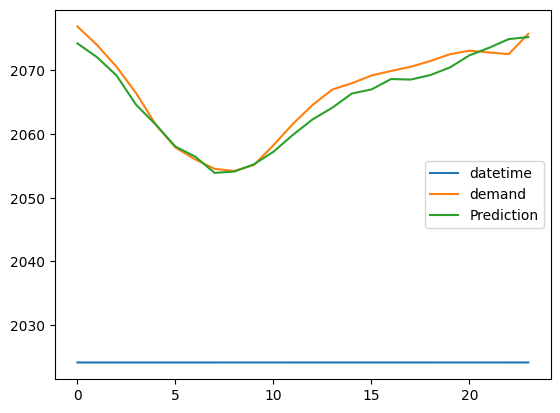

In [4]:
import sys
sys.path.append("C:\\Users\\ErickDavid\\Documents\\Repos\\ml-forecast-cenace")

from data_retrieval.collector import collect_data_api
from data_retrieval.collector import aggregate_data
from model.ml_model import data_to_seq2seq
import time
import joblib
import polars as pl
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import hvplot



def data_prepare_last_week():
    print("This is predictor")
    start_epoch = int(time.time()) - 27*24*60*60 + 1
    end_epoch = start_epoch + 8*24*60*60

    data = collect_data_api(system="NAC", start_epoch= start_epoch, end_epoch= end_epoch)

    data = aggregate_data(data)
    print(data)
    scaler = joblib.load("../model/tran_scaler.save")

    data_to_model = data.select(pl.col(['demand']))

    data_to_model =  pl.DataFrame(scaler.transform(data_to_model))



    X = data_to_model[:-24]
    print(X)

    model = tf.keras.models.load_model("../model/Model-12-03-2024-19-38-MAE0.04.keras")
    # model.summary()

    y_pred = model.predict(X.to_numpy()[np.newaxis, :-24])[0,-1]
    print(y_pred.shape)
    print("**********")
    print(data_to_model[-24:].to_numpy()[:,0].shape)
    # a = y_pred - data_to_model[-24:].to_numpy()
    print("**********")
    print(sum(abs(y_pred-data_to_model[-24:].to_numpy()[:,0])))

    print(y_pred)
    print(data_to_model[-24:].to_numpy()[:,0])

    # plt.plot(np.arange(0, 24), data_to_model[-24:].to_numpy()[:,0], label ="Real")
    # plt.plot(np.arange(0, 24), y_pred, label = "Prediction")
    # plt.legend(loc="upper left")
    # plt.show()

    real = pl.DataFrame(data.select(pl.col(['datetime','demand']))[-24:])
    prediction = pl.DataFrame(scaler.inverse_transform(y_pred.reshape(-1,1)), schema=['Prediction'])
    final =  pl.concat([real,prediction], how='horizontal')
    final.to_pandas().plot()



data_prepare_last_week()